# Phase 5A — Traditional Machine Learning Models

## Modeling Dataset Initialization

In this step, the preprocessed and leakage-safe modeling dataset is loaded and inspected before model training.

The dataset has been constructed in previous phases using a strictly temporal pipeline:

- Labels are defined using only future interactions within a 3-day horizon
- All features are computed using information available before the prediction timestamp
- A chronological train/validation/test split with safety gaps has been applied to prevent temporal leakage

The purpose of this step is therefore not to modify the dataset, but to:

- Verify dataset consistency (shape, columns, segments)
- Inspect potential data quality issues (missing values, duplicates)
- Confirm the integrity of the predefined temporal split

No feature engineering or transformations are performed at this stage.

## Use of Identifiers

Identifier variables (user_id, streamer_name, prediction_time) are retained in the dataset for validation, analysis, and traceability purposes.

These variables are strictly excluded from the feature set used for model training and prediction.

This ensures that no information leakage occurs, while allowing detailed post-hoc analysis such as error inspection and subgroup evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from itertools import product

In [3]:
df = pd.read_csv("../data_processed/model_dataset_100k_3day_features_v1.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2380571, 30)


,user_id,streamer_name,prediction_time,user_past_sessions,user_total_watch_time,user_avg_session_duration,user_recency,user_has_history,streamer_past_sessions,streamer_total_watch_time,...,time_sin_week,time_cos_week,user_unique_streamers,streamer_unique_users,user_repeat_ratio,streamer_repeat_audience_ratio,pair_watch_share_user,pair_watch_share_streamer,label,segment
0,847,catsonurhead,0,0,0,0.0,NaN,0,0,0,...,0.0,1.0,0,0,0.0,0.0,0.0,0.0,0,train
1,86110,riverfoxtv,0,0,0,0.0,NaN,0,0,0,...,0.0,1.0,0,0,0.0,0.0,0.0,0.0,0,train
2,95292,solaryfortnite,0,0,0,0.0,NaN,0,0,0,...,0.0,1.0,0,0,0.0,0.0,0.0,0.0,1,train
3,80024,risenhaha,0,0,0,0.0,NaN,0,0,0,...,0.0,1.0,0,0,0.0,0.0,0.0,0.0,1,train
4,76125,blondynkitezgraja,0,0,0,0.0,NaN,0,0,0,...,0.0,1.0,0,0,0.0,0.0,0.0,0.0,0,train


In [4]:
# Check missing values
print("Missing values:", df.isnull().sum().sum())

Missing values: 1553924


### Handling of Missing Values in Recency Features

In the final modeling dataset, missing values are present exclusively in recency-based features (user_recency, streamer_recency, and pair_recency). These missing values do not arise from data quality issues, but are instead a direct consequence of how recency is defined.

The dataset contains 2,380,571 observations and 27 columns, resulting in approximately 64 million data points. Out of these, a total of 1,553,924 values are missing, corresponding to roughly 2.4% of all values.

All missing values originate from recency features and are distributed as follows:

- user_recency: 119,554 missing values (~5.0%)
- streamer_recency: 154,980 missing values (~6.5%)
- pair_recency: 1,279,390 missing values (~53.7%)

These missing values occur because recency is only defined when prior interactions exist. Specifically:

- user_recency is missing for users appearing for the first time  
- streamer_recency is missing for newly observed streamers  
- pair_recency is missing when a user interacts with a streamer for the first time  

Due to the sparsity of the user–streamer interaction graph, first-time interactions are particularly common at the pair level. As a result, a substantial proportion of observations correspond to previously unseen user–streamer pairs, leading to a high proportion of missing values in pair_recency.

Importantly, these missing values are structurally meaningful. They encode the absence of prior interaction history and therefore provide information about whether an interaction is novel or repeated. Treating these values as standard missing data would obscure this distinction.

To preserve this information, dedicated binary indicator features are introduced:

- user_has_history  
- streamer_has_history  
- pair_has_history  

These indicators explicitly differentiate between:

- first-time observations (no prior history)  
- repeated interactions (where recency is defined)  

During model training, missing values in recency features are handled via constant-value imputation (set to -1) within the modeling pipeline, while the corresponding indicator variables ensure that the semantic distinction between “no history” and “low recency” is retained.

Overall, this design reflects the temporal and structural properties of the dataset, ensuring that missing values are interpreted as informative signals rather than artifacts of incomplete data.

In [5]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
print("\nColumns in dataset:")
print(df.columns.tolist())


Columns in dataset:
['user_id', 'streamer_name', 'prediction_time', 'user_past_sessions', 'user_total_watch_time', 'user_avg_session_duration', 'user_recency', 'user_has_history', 'streamer_past_sessions', 'streamer_total_watch_time', 'streamer_avg_session_duration', 'streamer_recency', 'streamer_has_history', 'pair_past_sessions', 'pair_total_watch_time', 'pair_avg_session_duration', 'pair_recency', 'pair_has_history', 'time_sin_day', 'time_cos_day', 'time_sin_week', 'time_cos_week', 'user_unique_streamers', 'streamer_unique_users', 'user_repeat_ratio', 'streamer_repeat_audience_ratio', 'pair_watch_share_user', 'pair_watch_share_streamer', 'label', 'segment']


In [7]:
print("Total columns:", len(df.columns))

Total columns: 30


In [8]:
print("\nSegment distribution:")
print(df["segment"].value_counts())


Segment distribution:
segment
train         1373160
validation     520761
test           486650
Name: count, dtype: int64


In [9]:
print("\nOverall label distribution:")
print(df["label"].value_counts(normalize=True))

print("\nLabel distribution by segment:")
print(df.groupby("segment")["label"].mean())


Overall label distribution:
label
0    0.772046
1    0.227954
Name: proportion, dtype: float64

Label distribution by segment:
segment
test          0.239721
train         0.219275
validation    0.239843
Name: label, dtype: float64


### Dataset Sanity Checks

The dataset does not contain duplicate rows, confirming that each observation corresponds to a unique prediction anchor.

The temporal split distribution shows a sufficient number of samples in each segment, ensuring reliable training, validation, and testing.

The overall positive label rate is approximately 22.8%, indicating a moderately imbalanced classification problem.

Importantly, the label distribution remains stable across train, validation, and test segments. This suggests that no significant temporal distribution shift is present, supporting the validity of the chronological split for out-of-sample evaluation.

## Final dataset state before modeling

At this stage, the dataset represents the final modeling input for Phase 5A.

All observations correspond to unique prediction anchors, and no exact duplicate rows are present in the dataset.

The dataset has been constructed using a strictly leakage-safe temporal pipeline, where all features are derived exclusively from information available prior to the prediction timestamp.

This final dataset is used as the fixed input for all traditional machine learning models to ensure a fair and consistent comparison across models.

In [10]:
# Define final feature columns explicitly (leakage-safe)

FEATURE_COLUMNS = [

    # --- User-level features ---
    "user_past_sessions",
    "user_total_watch_time",
    "user_avg_session_duration",
    "user_recency",
    "user_has_history",

    # --- Streamer-level features ---
    "streamer_past_sessions",
    "streamer_total_watch_time",
    "streamer_avg_session_duration",
    "streamer_recency",
    "streamer_has_history",

    # --- User–streamer interaction features ---
    "pair_past_sessions",
    "pair_total_watch_time",
    "pair_avg_session_duration",
    "pair_recency",
    "pair_has_history",

    # --- Temporal features ---
    "time_sin_day",
    "time_cos_day",
    "time_sin_week",
    "time_cos_week",

    # --- Structural / behavioral features ---
    "user_unique_streamers",
    "streamer_unique_users",
    "user_repeat_ratio",
    "streamer_repeat_audience_ratio",
    "pair_watch_share_user",
    "pair_watch_share_streamer",
]

TARGET = "label"
SPLIT_COL = "segment"

## Train, validation, and test split

The final feature dataset is split using the predefined temporal segment assignments constructed in Phase 3.

No reshuffling is performed, so the chronological structure of the data is preserved.

The validation set is used for model selection and threshold tuning.
The test set remains untouched until the final evaluation step to ensure valid out-of-sample assessment.

In [11]:
train_df = df[df["segment"] == "train"].copy()
val_df   = df[df["segment"] == "validation"].copy()
test_df  = df[df["segment"] == "test"].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET]

X_val = val_df[FEATURE_COLUMNS]
y_val = val_df[TARGET]

X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET]

print("\nX_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

Train shape: (1373160, 30)
Validation shape: (520761, 30)
Test shape: (486650, 30)

X_train: (1373160, 25) y_train: (1373160,)
X_val  : (520761, 25) y_val  : (520761,)
X_test : (486650, 25) y_test : (486650,)


## Logistic Regression Baseline

Logistic Regression is used as the first traditional baseline model.

Since the model is sensitive to feature scale, all input features are standardized using statistics computed from the training data only.

Evaluation is performed on the validation set using:
- ROC-AUC (threshold-independent)
- F1-score (threshold-dependent)

The classification threshold is selected based on validation performance.

Missing values in recency-based features are handled via constant-value imputation (set to -1) within the modeling pipeline.

In [12]:
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    ))
])

In [13]:
lr_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'constant'
,fill_value,-1
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


Predicted probabilities for the positive class (re-engagement) are computed on the validation set. These probabilities will be used for threshold selection and evaluation.

In [14]:
val_probs = lr_pipeline.predict_proba(X_val)[:, 1]

The classification threshold is selected based on validation performance by maximizing the F1-score. This approach is preferred due to the class imbalance in the dataset, as F1-score balances precision and recall.

Threshold tuning is performed exclusively on the validation set to avoid biasing the final evaluation on the test set.

In [15]:
def evaluate_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0)
    }

def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.0, 1.0, 101)
    best = None
    
    for t in thresholds:
        res = evaluate_threshold(y_true, y_prob, t)
        if best is None or res["f1"] > best["f1"]:
            best = res
            
    return best

In [16]:
res_05 = evaluate_threshold(y_val, val_probs, 0.5)
res_best = find_best_threshold(y_val, val_probs)

print("Validation @ 0.5:")
for k, v in res_05.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\nBest validation threshold (selected by F1):")
for k, v in res_best.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Validation @ 0.5:
threshold: 0.5000
roc_auc: 0.7057
f1: 0.3087
precision: 0.5358
recall: 0.2168

Best validation threshold (selected by F1):
threshold: 0.2600
roc_auc: 0.7057
f1: 0.4798
precision: 0.3807
recall: 0.6485


## Final evaluation on test set (Logistic Regression)

The Logistic Regression model is evaluated on the test set using the threshold selected on the validation set.

The test set is not used during model training or threshold selection.

This ensures a fair evaluation of out-of-sample generalization performance.

In [35]:
best_threshold = res_best["threshold"]

test_probs = lr_pipeline.predict_proba(X_test)[:, 1]

test_result = evaluate_threshold(y_test, test_probs, best_threshold)
test_result["pr_auc"] = average_precision_score(y_test, test_probs)

print("Test results (Logistic Regression):")
for k, v in test_result.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Test results (Logistic Regression):
threshold: 0.2600
roc_auc: 0.7054
f1: 0.4800
precision: 0.3776
recall: 0.6586
pr_auc: 0.4403


## Logistic Regression Baseline Summary

As a first baseline model, Logistic Regression is applied to predict whether a user will re-engage with the same streamer within a 3-day horizon.

### Model Setup

- Input features consist of user, streamer, interaction, temporal, and structural signals derived from past behavior.
- Missing values in recency-based features are handled via constant-value imputation (set to -1) within the modeling pipeline.
- All features are standardized using statistics computed on the training set only.
- A strict temporal split (train / validation / test) is used to prevent information leakage.
- Model hyperparameters are kept simple to establish a clean and interpretable baseline.

### Threshold Selection

Since the dataset is imbalanced (~22–24% positive class), using the default classification threshold (0.5) leads to suboptimal performance.  
Therefore, the classification threshold is selected based on validation performance by maximizing the F1-score.

The optimal threshold was found to be:

- **Threshold = 0.26**

### Results

#### Validation Set

- ROC-AUC: 0.7057  
- F1-score: 0.4798  
- Precision: 0.3807  
- Recall: 0.6485  

#### Test Set

- ROC-AUC: 0.7054  
- F1-score: 0.4800  
- Precision: 0.3776  
- Recall: 0.6586  

### Key Observations

- The model achieves a solid baseline performance (ROC-AUC ≈ 0.70), indicating that historical behavioral features carry meaningful predictive signal.
- Validation and test results are highly consistent, suggesting good generalization and no strong evidence of overfitting.
- Lowering the classification threshold substantially improves recall and overall F1-score, highlighting the importance of threshold tuning in imbalanced settings.
- The model favors recall over precision, meaning it is more effective at identifying potential re-engagement events than avoiding false positives.

### Interpretation

These results demonstrate that user re-engagement on live streaming platforms can be predicted with moderate accuracy using simple linear models and carefully engineered behavioral features.

This baseline provides a strong and interpretable reference point for evaluating more complex models, such as tree-based and graph-based approaches.

## XGBoost Model

To capture potential nonlinear relationships and interaction effects between features, an XGBoost classifier is used as an additional, more flexible model

Unlike Logistic Regression, XGBoost does not require feature scaling and can capture nonlinear relationships and feature interactions

The same feature set and temporal data split are used to ensure a fair comparison with the Logistic Regression baseline.

Model selection is performed on the validation set, and the classification threshold is tuned based on F1-score.

Missing values in recency-based features are handled consistently with the Logistic Regression baseline using constant-value imputation (-1).

In [18]:
xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [19]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'constant'
,fill_value,-1
,copy,True
,add_indicator,False
,keep_empty_features,False
,objective,'binary:logistic'


In [20]:
val_probs_xgb = xgb_pipeline.predict_proba(X_val)[:, 1]

In [21]:
res_05_xgb = evaluate_threshold(y_val, val_probs_xgb, 0.5)
res_best_xgb = find_best_threshold(y_val, val_probs_xgb)

print("Validation @ 0.5 (XGBoost):")
for k, v in res_05_xgb.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\nBest validation threshold (selected by F1) (XGBoost):")
for k, v in res_best_xgb.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Validation @ 0.5 (XGBoost):
threshold: 0.5000
roc_auc: 0.7052
f1: 0.3085
precision: 0.5361
recall: 0.2166

Best validation threshold (selected by F1) (XGBoost):
threshold: 0.2500
roc_auc: 0.7052
f1: 0.4789
precision: 0.3755
recall: 0.6606


In [22]:
best_threshold_xgb = res_best_xgb["threshold"]

test_probs_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

test_result_xgb = evaluate_threshold(y_test, test_probs_xgb, best_threshold_xgb)

print("Test results (XGBoost):")
for k, v in test_result_xgb.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Test results (XGBoost):
threshold: 0.2500
roc_auc: 0.6983
f1: 0.4732
precision: 0.3635
recall: 0.6778


## Controlled hyperparameter tuning for XGBoost

After establishing untuned baseline models, a limited hyperparameter search is performed for XGBoost using validation ROC-AUC for model selection.

The goal is not exhaustive optimization, but to test whether a reasonably tuned nonlinear model can improve over the Logistic Regression baseline under the same leakage-safe evaluation setup.

To keep the tuning procedure computationally efficient and methodologically transparent, threshold tuning is not repeated for every hyperparameter combination. Instead, hyperparameter selection is first based on validation ROC-AUC, after which the classification threshold is tuned only once for the best-performing model using validation F1-score.

The search is intentionally kept small and transparent to avoid overfitting the validation set and to maintain methodological clarity.

In [23]:
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos

print("Positive samples:", pos)
print("Negative samples:", neg)
print("scale_pos_weight:", round(scale_pos_weight, 4))

Positive samples: 301099
Negative samples: 1072061
scale_pos_weight: 3.5605


In [24]:
param_grid = {
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 300],
    "scale_pos_weight": [1, scale_pos_weight]
}

In [25]:
results = []

all_combinations = list(product(
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["n_estimators"],
    param_grid["scale_pos_weight"]
))

print("Total combinations:", len(all_combinations))

for max_depth, learning_rate, n_estimators, spw in all_combinations:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
        ("model", XGBClassifier(
            max_depth=max_depth,
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=spw,
            random_state=42,
            eval_metric="logloss"
        ))
    ])

    model.fit(X_train, y_train)
    val_probs = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_probs)

    results.append({
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "scale_pos_weight": spw,
        "val_roc_auc": val_auc
    })

results_df = pd.DataFrame(results).sort_values(
    by="val_roc_auc",
    ascending=False
).reset_index(drop=True)

results_df.head(10)

Total combinations: 16


,max_depth,learning_rate,n_estimators,scale_pos_weight,val_roc_auc
0,4,0.05,200,1.000000,0.709614
1,6,0.05,200,1.000000,0.709175
2,4,0.05,200,3.560493,0.709019
3,4,0.05,300,1.000000,0.708662
4,6,0.05,300,1.000000,0.708219
5,4,0.05,300,3.560493,0.708072
6,4,0.10,200,1.000000,0.708022
7,4,0.10,300,1.000000,0.706680
8,6,0.05,200,3.560493,0.706540
9,4,0.10,200,3.560493,0.706243


In [26]:
best_params = results_df.iloc[0].to_dict()

print("Best hyperparameters based on validation ROC-AUC:")
for k, v in best_params.items():
    print(f"{k}: {v}")

Best hyperparameters based on validation ROC-AUC:
max_depth: 4.0
learning_rate: 0.05
n_estimators: 200.0
scale_pos_weight: 1.0
val_roc_auc: 0.709614338205634


In [28]:
best_xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("model", XGBClassifier(
        max_depth=int(best_params["max_depth"]),
        learning_rate=float(best_params["learning_rate"]),
        n_estimators=int(best_params["n_estimators"]),
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=float(best_params["scale_pos_weight"]),
        random_state=42,
        eval_metric="logloss"
    ))
])

In [29]:
best_xgb_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'constant'
,fill_value,-1
,copy,True
,add_indicator,False
,keep_empty_features,False
,objective,'binary:logistic'


In [30]:
val_probs_best_xgb = best_xgb_pipeline.predict_proba(X_val)[:, 1]

In [31]:
res_05_best_xgb = evaluate_threshold(y_val, val_probs_best_xgb, 0.5)
res_best_best_xgb = find_best_threshold(y_val, val_probs_best_xgb)

print("Validation @ 0.5 (Tuned XGBoost):")
for k, v in res_05_best_xgb.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\nBest validation threshold (selected by F1) (Tuned XGBoost):")
for k, v in res_best_best_xgb.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Validation @ 0.5 (Tuned XGBoost):
threshold: 0.5000
roc_auc: 0.7096
f1: 0.3154
precision: 0.5406
recall: 0.2226

Best validation threshold (selected by F1) (Tuned XGBoost):
threshold: 0.2500
roc_auc: 0.7096
f1: 0.4825
precision: 0.3782
recall: 0.6661


In [36]:
best_threshold_tuned_xgb = res_best_best_xgb["threshold"]

test_probs_best_xgb = best_xgb_pipeline.predict_proba(X_test)[:, 1]
test_result_best_xgb = evaluate_threshold(y_test, test_probs_best_xgb, best_threshold_tuned_xgb)
test_result_best_xgb["pr_auc"] = average_precision_score(y_test, test_probs_best_xgb)

print("Test results (Tuned XGBoost):")
for k, v in test_result_best_xgb.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Test results (Tuned XGBoost):
threshold: 0.2500
roc_auc: 0.7064
f1: 0.4779
precision: 0.3678
recall: 0.6822
pr_auc: 0.4395


### Tuned XGBoost summary

The tuned XGBoost model achieves slightly higher ROC-AUC than the Logistic Regression baseline, indicating marginally improved ranking performance. However, gains in F1-score are limited, and overall performance remains comparable across models.

These results suggest that while nonlinear modeling provides a small improvement, the predictive signal is already largely captured by the engineered features.

## Majority-Class Baseline

Before evaluating learned models, a majority-class baseline is established. This baseline always predicts the negative class (no re-engagement), representing the minimum performance any useful model must exceed.

The random baseline predicts the positive class according to the observed class distribution in the training set.

In [37]:
# Majority class baseline: always predict 0 (no re-engagement)
majority_probs = np.zeros(len(y_test))
majority_preds = np.zeros(len(y_test), dtype=int)

# Random baseline: predict positive at the prior rate
prior = y_train.mean()
np.random.seed(42)
random_preds = (np.random.rand(len(y_test)) < prior).astype(int)
random_probs = np.full(len(y_test), prior)

baseline_results = pd.DataFrame([
    {
        "model": "Majority Class (always 0)",
        "test_roc_auc": roc_auc_score(y_test, majority_probs),
        "test_f1": 0.0,
        "test_precision": 0.0,
        "test_recall": 0.0,
    },
    {
        "model": "Random Baseline (prior rate)",
        "test_roc_auc": roc_auc_score(y_test, random_probs),
        "test_f1": f1_score(y_test, random_preds),
        "test_precision": precision_score(y_test, random_preds, zero_division=0),
        "test_recall": recall_score(y_test, random_preds, zero_division=0),
    }
])

print(baseline_results.to_string(index=False))

                       model  test_roc_auc  test_f1  test_precision  test_recall
   Majority Class (always 0)           0.5 0.000000        0.000000     0.000000
Random Baseline (prior rate)           0.5 0.229449        0.240229     0.219595


Both learned models substantially outperform the baselines, achieving approximately double the F1-score of the random predictor. This confirms that the models capture meaningful predictive signal beyond simple class distribution heuristics.

## Final Model Comparison (Traditional Models)

This section presents the final comparison between Logistic Regression and XGBoost using the same feature set and leakage-safe temporal split.

For each model:
- The best threshold is selected on the validation set
- The same threshold is applied to the test set
- Performance is evaluated using ROC-AUC (primary metric), F1-score, and PR-AUC

PR-AUC is additionally reported due to class imbalance, providing a more informative evaluation of performance on the positive class.

This ensures a fair and consistent comparison across models.

In [38]:
results_summary = pd.DataFrame([
    {
        "model": "Majority Class Baseline",
        "val_roc_auc": np.nan,
        "val_pr_auc": np.nan,
        "val_f1": np.nan,
        "val_best_threshold": "-",
        "test_roc_auc": 0.500,
        "test_pr_auc": np.nan,
        "test_f1": 0.000,
        "test_precision": 0.000,
        "test_recall": 0.000,
    },
    {
        "model": "Logistic Regression",
        "val_roc_auc": res_best["roc_auc"],
        "val_pr_auc": np.nan,
        "val_f1": res_best["f1"],
        "val_best_threshold": round(res_best["threshold"], 4),
        "test_roc_auc": test_result["roc_auc"],
        "test_pr_auc": test_result["pr_auc"],
        "test_f1": test_result["f1"],
        "test_precision": test_result["precision"],
        "test_recall": test_result["recall"],
    },
    {
        "model": "XGBoost (tuned)",
        "val_roc_auc": res_best_best_xgb["roc_auc"],
        "val_pr_auc": np.nan,
        "val_f1": res_best_best_xgb["f1"],
        "val_best_threshold": round(res_best_best_xgb["threshold"], 4),
        "test_roc_auc": test_result_best_xgb["roc_auc"],
        "test_pr_auc": test_result_best_xgb["pr_auc"],
        "test_f1": test_result_best_xgb["f1"],
        "test_precision": test_result_best_xgb["precision"],
        "test_recall": test_result_best_xgb["recall"],
    }
])

results_summary

,model,val_roc_auc,val_pr_auc,val_f1,val_best_threshold,test_roc_auc,test_pr_auc,test_f1,test_precision,test_recall
0,Majority Class Baseline,NaN,NaN,NaN,-,0.50000,NaN,0.000000,0.000000,0.00000
1,Logistic Regression,0.705674,NaN,0.479751,0.26,0.70540,0.440335,0.480013,0.377625,0.65858
2,XGBoost (tuned),0.709614,NaN,0.482482,0.25,0.70638,0.439507,0.477924,0.367785,0.68223


In [42]:
TABLE_PATH = Path("../reports/modeling/tables/traditional_models_results.csv")

results_summary.to_csv(TABLE_PATH, index=False)

print("Saved to:", TABLE_PATH)

Saved to: ../reports/modeling/tables/traditional_models_results.csv


## Confusion Matrix Analysis (Test Set)

To better understand model behavior, confusion matrices are analyzed on the test set using the selected validation thresholds.

This helps interpret:
- False positives vs false negatives
- Precision–recall trade-offs
- Model decision tendencies

Confusion matrices are plotted for Logistic Regression and the tuned XGBoost model using `ConfusionMatrixDisplay` for correct axis labeling and thesis-ready formatting.

In [43]:
def plot_conf_matrix(y_true, y_probs, threshold, title, save_path=None):
    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Return (0)", "Return (1)"]
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(title)
    plt.tight_layout()

    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
        print("Saved to:", save_path)

    plt.show()

Saved to: ../reports/modeling/figures/lr_confusion_matrix.png


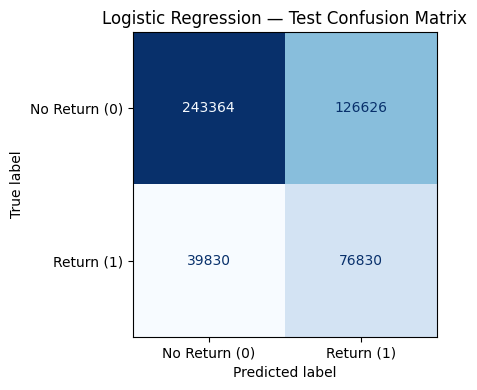

Saved to: ../reports/modeling/figures/xgb_confusion_matrix.png


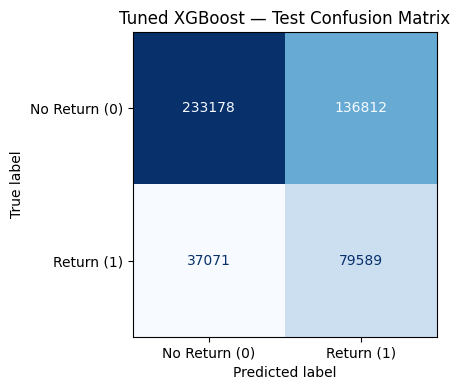

In [44]:
FIG_PATH = Path("../reports/modeling/figures")

plot_conf_matrix(
    y_test,
    test_probs,
    res_best["threshold"],
    "Logistic Regression — Test Confusion Matrix",
    save_path=FIG_PATH / "lr_confusion_matrix.png"
)

plot_conf_matrix(
    y_test,
    test_probs_best_xgb,
    res_best_best_xgb["threshold"],
    "Tuned XGBoost — Test Confusion Matrix",
    save_path=FIG_PATH / "xgb_confusion_matrix.png"
)

The confusion matrices reveal a clear difference in decision behavior between the models. 

Both models favor recall over precision at the selected thresholds; however, the tuned XGBoost model is more aggressive in predicting re-engagement. Compared to Logistic Regression, it correctly identifies more returning users (higher true positives) and misses fewer actual returns (lower false negatives), but at the cost of a higher number of false positives.

This indicates that XGBoost prioritizes capturing potential re-engagement events, whereas Logistic Regression adopts a more conservative decision boundary with fewer false alarms.

## ROC Curve

The ROC curves compare the threshold-independent ranking performance of Logistic Regression and tuned XGBoost on the test set. Since ROC-AUC is the primary evaluation metric, this visualization supports the final model comparison.

In [ ]:
def plot_roc_comparison(y_true, lr_probs, xgb_probs, save_path=None):
    lr_fpr, lr_tpr, _ = roc_curve(y_true, lr_probs)
    xgb_fpr, xgb_tpr, _ = roc_curve(y_true, xgb_probs)

    lr_auc = roc_auc_score(y_true, lr_probs)
    xgb_auc = roc_auc_score(y_true, xgb_probs)

    plt.figure(figsize=(6, 5))
    plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.4f})")
    plt.plot(xgb_fpr, xgb_tpr, label=f"Tuned XGBoost (AUC = {xgb_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison (Test Set)")
    plt.legend(loc="lower right")
    plt.tight_layout()

    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
        print("Saved to:", save_path)

    plt.show()

Saved to: ../reports/modeling/figures/traditional_models_roc_curve.png


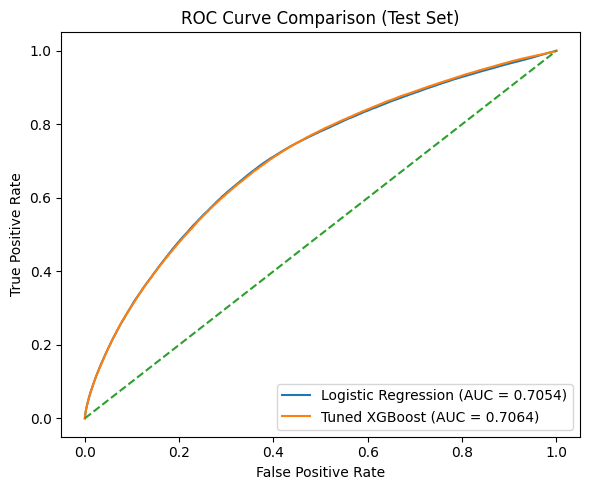

In [47]:
plot_roc_comparison(
    y_test,
    test_probs,
    test_probs_best_xgb,
    FIG_PATH / "traditional_models_roc_curve.png"
)

The ROC curves of Logistic Regression and tuned XGBoost are nearly identical, with only a negligible difference in AUC (≈ 0.001). This indicates that both models have almost the same ability to rank re-engagement likelihoods.

Combined with the confusion matrix analysis, this suggests that the models differ primarily in their decision behavior at a given threshold rather than in their overall predictive capacity.

## Final Interpretation

The experimental results show that Logistic Regression provides a strong baseline for predicting user re-engagement, achieving a ROC-AUC of approximately 0.70 and an F1-score of around 0.48 on the test set.

After hyperparameter tuning, XGBoost achieves nearly identical performance, with only negligible improvements in both ROC-AUC and F1-score (differences < 0.01). The ROC curves of the two models are almost perfectly overlapping, indicating that they have a similar ability to rank re-engagement likelihoods.

Despite this similarity in ranking performance, the confusion matrix analysis reveals meaningful differences in decision behavior. The tuned XGBoost model identifies more true re-engagement events (higher true positives) and misses fewer returning users (lower false negatives), but at the cost of producing more false positives. In contrast, Logistic Regression adopts a more conservative decision boundary.

This suggests that the models differ primarily in how they trade off precision and recall at a given threshold, rather than in their overall predictive capacity.

The close alignment between validation and test performance confirms the robustness of the experimental setup and indicates that overfitting is not a concern.

Overall, the findings suggest that the engineered behavioral features already capture a substantial portion of the predictive signal, and that increasing model complexity alone does not lead to significant performance gains. This motivates the exploration of graph-based models, which may better leverage the underlying relational structure of user–streamer interactions.